# Loss-weight ablation benchmark

Investigates how each of BIBOLA's four loss terms (`abs_lisa_loss`, `topology_loss`,
`knn_loss`, `reconstruction_loss`) contributes to the final corrected representation, by
training `BaseIntegration` on a simulated dataset with a known ground truth (cell type +
batch labels) and silencing (weight = 0) each loss term in turn.

The decoder used for `reconstruction_loss` is conditioned on the sample's batch (a one-hot
of its batch id is concatenated to the transformed representation before decoding), so
reconstruction quality reflects batch-aware decoding, not a single batch-agnostic decoder.

Configs trained:
- `baseline` — all four weights = 1.0
- `no_lisa` — `abs_lisa_loss` weight = 0
- `no_topology` — `topology_loss` weight = 0
- `no_knn` — `knn_loss` weight = 0
- `no_reconstruction` — `reconstruction_loss` weight = 0

Each config is trained from the same initial weights (same seed) on the same data, so the
only difference between runs is which loss term drives training. Evaluated on metrics that
are *not* the training losses themselves (silhouette scores, cluster purity, centroid
geometry, raw reconstruction error), to avoid circularity.

In [1]:
import copy

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

from bibola.model import BaseIntegration

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

## Simulated dataset

`n_types` ground-truth subpopulations (e.g. cell types), each present in every one of
`n_batches` batches. Each batch applies its own fixed additive shift to every feature — a
batch effect that raw PCA/clustering would pick up as the dominant axis of variation, on top
of the real type structure. Type and batch labels are both known, so we can measure batch
mixing and type preservation separately after correction.

X: (1200, 1000), 4 cell types, 3 batches


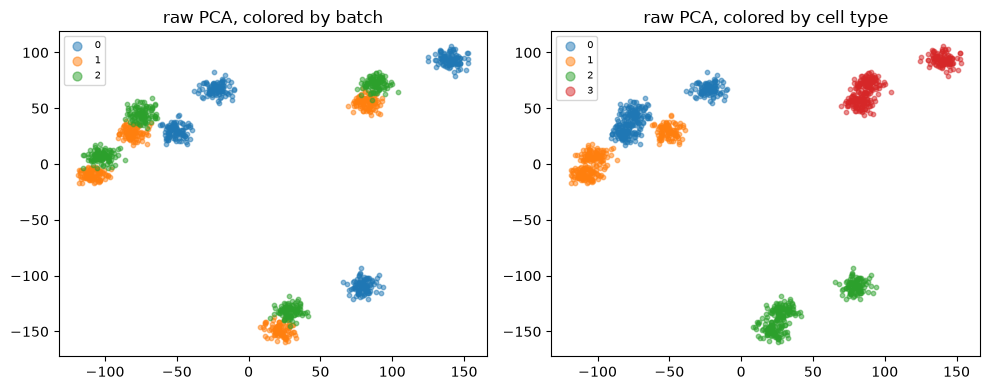

In [2]:
def simulate_data(n_types=4, n_batches=3, n_per_type_per_batch=100, n_features=1000,
                   type_sep=5.0, batch_shift_scale=4.0, noise_std=5.0, seed=0):
    rng = np.random.default_rng(seed)

    type_centers = rng.normal(scale=type_sep, size=(n_types, n_features))
    batch_shifts = rng.normal(scale=batch_shift_scale, size=(n_batches, n_features))
    batch_shifts -= batch_shifts.mean(axis=0, keepdims=True)  # keep the overall data centered

    X, cell_type, batch = [], [], []
    for b in range(n_batches):
        for t in range(n_types):
            pts = (type_centers[t] + batch_shifts[b]
                   + rng.normal(scale=noise_std, size=(n_per_type_per_batch, n_features)))
            X.append(pts)
            cell_type += [t] * n_per_type_per_batch
            batch += [b] * n_per_type_per_batch

    X = np.concatenate(X, axis=0).astype(np.float32)
    return X, np.array(cell_type), np.array(batch)


X, cell_type, batch = simulate_data(seed=SEED)
print(f"X: {X.shape}, {len(np.unique(cell_type))} cell types, {len(np.unique(batch))} batches")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
X_pca = PCA(n_components=2, random_state=SEED).fit_transform(X)
for ax, labels, title in zip(axes, [batch, cell_type], ["batch", "cell type"]):
    for value in np.unique(labels):
        mask = labels == value
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, label=str(value), alpha=0.5)
    ax.set_title(f"raw PCA, colored by {title}")
    ax.legend(fontsize=7, markerscale=2)
plt.tight_layout()

## Ablation configs

Each config trains a freshly-initialized `BaseIntegration` (same architecture, same seed for
model init) on the same simulated data, epochs, and hyperparameters — the *only* thing that
differs between runs is which loss term is silenced (weight set to 0).

In [3]:
FULL_WEIGHTS = {
    "abs_lisa_loss": 1.0,
    "topology_loss": 1.0,
    "knn_loss": 1.0,
    "reconstruction_loss": 1.0,
}

ABLATIONS = {
    "baseline": dict(FULL_WEIGHTS),
    "no_lisa": {**FULL_WEIGHTS, "abs_lisa_loss": 0.0},
    "no_topology": {**FULL_WEIGHTS, "topology_loss": 0.0},
    "no_knn": {**FULL_WEIGHTS, "knn_loss": 0.0},
    "no_reconstruction": {**FULL_WEIGHTS, "reconstruction_loss": 0.0},
}

MODEL_KWARGS = dict(in_channels=X.shape[1], hidden_channels=[32], out_channels=8, dropout=0.0)
FIT_KWARGS = dict(epochs=100, k_inter=5, k_intra=20, norm=2, optimizer_kwargs={"lr": 1e-2})

models, transformed = {}, {}
for name, loss_weights in ABLATIONS.items():
    torch.manual_seed(SEED)  # identical model init across configs
    model = BaseIntegration(**MODEL_KWARGS, optimizer_kwargs=FIT_KWARGS["optimizer_kwargs"])
    model.fit(
        X, batch, epochs=FIT_KWARGS["epochs"], k_inter=FIT_KWARGS["k_inter"],
        k_intra=FIT_KWARGS["k_intra"], norm=FIT_KWARGS["norm"], loss_weights=loss_weights,
        verbose=False
    )
    with torch.no_grad():
        X_transformed = model.transform(X, batch).numpy()

    models[name] = model
    transformed[name] = X_transformed
    final_loss = model.loss_history["loss"].iloc[-1]
    print(f"{name:>18}: " + ", ".join(f"{k}={v:.4f}" for k, v in final_loss.items()))

          baseline: abs_lisa_loss=0.0016, topology_loss=-0.8279, knn_loss=-0.9905, reconstruction_loss=0.6448


           no_lisa: abs_lisa_loss=0.0013, topology_loss=-0.8523, knn_loss=-0.9926, reconstruction_loss=0.6476


       no_topology: abs_lisa_loss=0.0014, topology_loss=-0.0738, knn_loss=-0.9968, reconstruction_loss=0.6410


            no_knn: abs_lisa_loss=0.0057, topology_loss=-0.8304, knn_loss=-0.6586, reconstruction_loss=0.6507


 no_reconstruction: abs_lisa_loss=0.0016, topology_loss=-0.8175, knn_loss=-0.9906, reconstruction_loss=2.2420


## Evaluation

Metrics are deliberately *not* the training losses themselves, so a config can't score well
on a metric just by construction:
- **batch silhouette** — silhouette score of the corrected embedding w.r.t. batch labels.
  Lower (more negative) means batches are better mixed (bad batches-as-clusters signal).
- **cell-type silhouette** — silhouette score w.r.t. the true cell-type labels. Higher means
  the biological subpopulations remain well separated (not over-corrected into a blob).
- **centroid distance correlation** — Pearson correlation between pairwise distances of the
  true per-type centroids before vs. after correction. Close to 1 means the type-level
  geometry (topology) survived correction.
- **reconstruction relative error** — same relative-L2 formula as `reconstruction_loss`,
  evaluated once after training regardless of whether that term drove training.

In [4]:
from scipy.spatial.distance import pdist


def evaluate(X_orig, X_transformed, cell_type, batch, model):
    orig_centroids = np.stack([X_orig[cell_type == t].mean(axis=0) for t in np.unique(cell_type)])
    trans_centroids = np.stack([X_transformed[cell_type == t].mean(axis=0) for t in np.unique(cell_type)])

    with torch.no_grad():
        X_t = torch.tensor(X_transformed, dtype=torch.float32)
        effect = model.effects[0]
        batch_ids_col = torch.tensor(pd.Series(batch).map(model.batch_dict[effect]).values, dtype=torch.int32).unsqueeze(1)
        batch_ohe = model._batch_ohe(batch_ids_col)
        X_hat = model.decoder(X_t, batch_ohe)
        X_orig_t = torch.tensor(X_orig, dtype=torch.float32)
        rel_error = (torch.norm(X_orig_t - X_hat, dim=1) / (torch.norm(X_orig_t, dim=1) + 1e-8)).mean().item()

    return {
        "batch_silhouette": silhouette_score(X_transformed, batch),
        "celltype_silhouette": silhouette_score(X_transformed, cell_type),
        "centroid_distance_corr": np.corrcoef(pdist(orig_centroids), pdist(trans_centroids))[0, 1],
        "reconstruction_rel_error": rel_error,
    }


results = pd.DataFrame({
    name: evaluate(X, transformed[name], cell_type, batch, models[name])
    for name in ABLATIONS
}).T
results.index.name = "config"
results.round(4)

,batch_silhouette,celltype_silhouette,centroid_distance_corr,reconstruction_rel_error
config,,,,
baseline,-0.0023,0.7989,0.6222,0.6454
no_lisa,-0.0000,0.8660,0.6014,0.6444
no_topology,-0.0010,0.7140,0.6060,0.6408
no_knn,0.0022,0.4549,0.8178,0.6505
no_reconstruction,-0.0030,0.4848,0.5981,2.2449


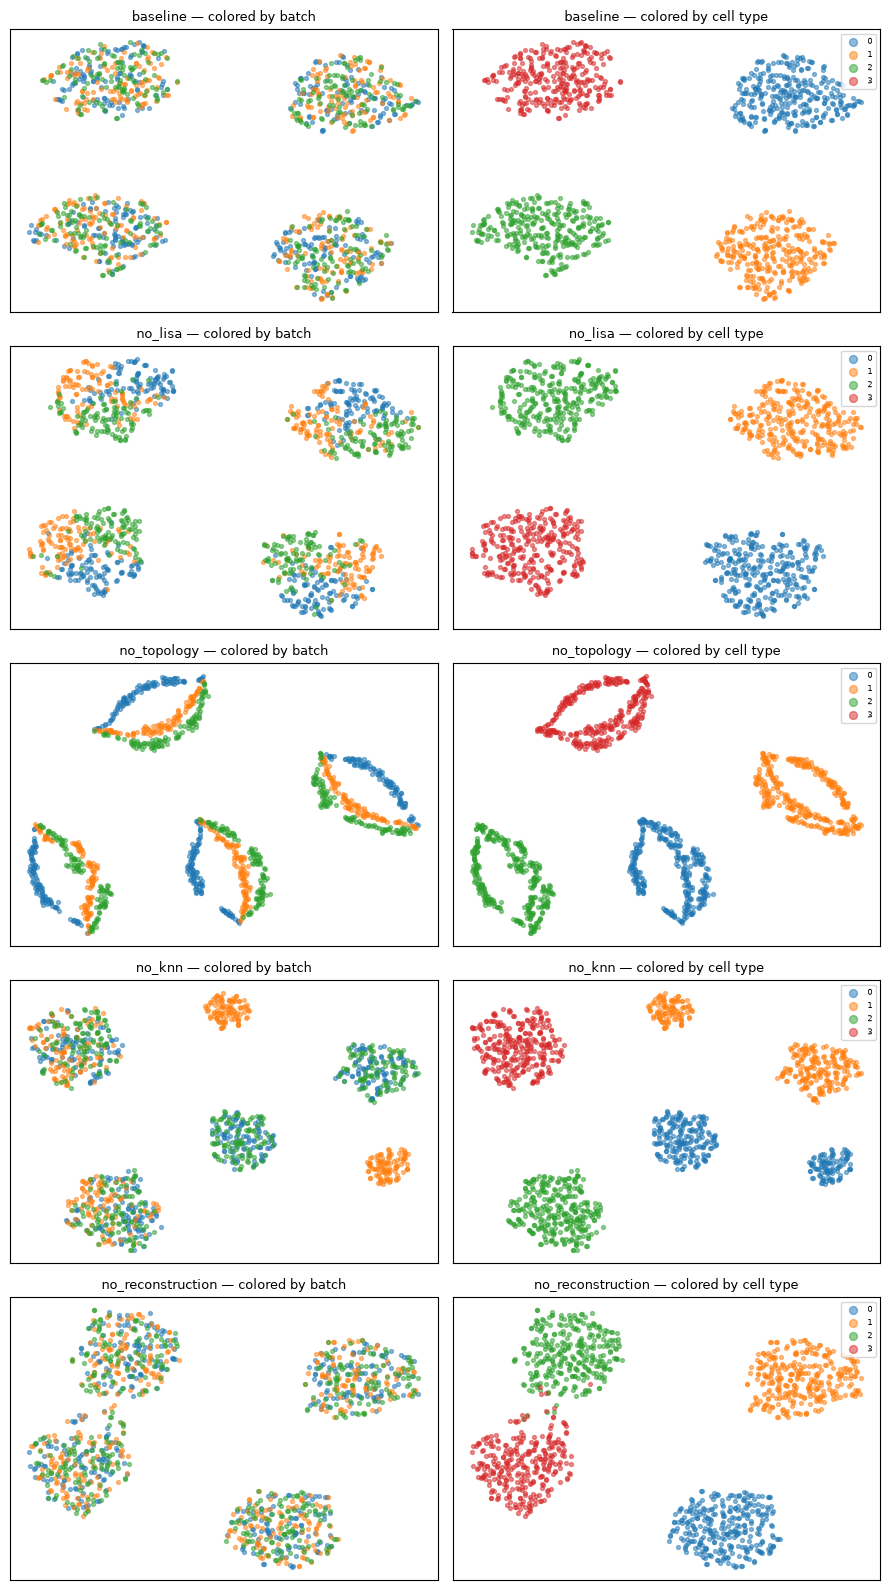

In [5]:
fig, axes = plt.subplots(len(ABLATIONS), 2, figsize=(9, 3.2 * len(ABLATIONS)))

for row, name in enumerate(ABLATIONS):
    emb = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(transformed[name])
    for col, (labels, title) in enumerate([(batch, "batch"), (cell_type, "cell type")]):
        ax = axes[row, col]
        for value in np.unique(labels):
            mask = labels == value
            ax.scatter(emb[mask, 0], emb[mask, 1], s=8, label=str(value), alpha=0.5)
        ax.set_title(f"{name} — colored by {title}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 1:
            ax.legend(fontsize=6, markerscale=2, loc="upper right")

plt.tight_layout()

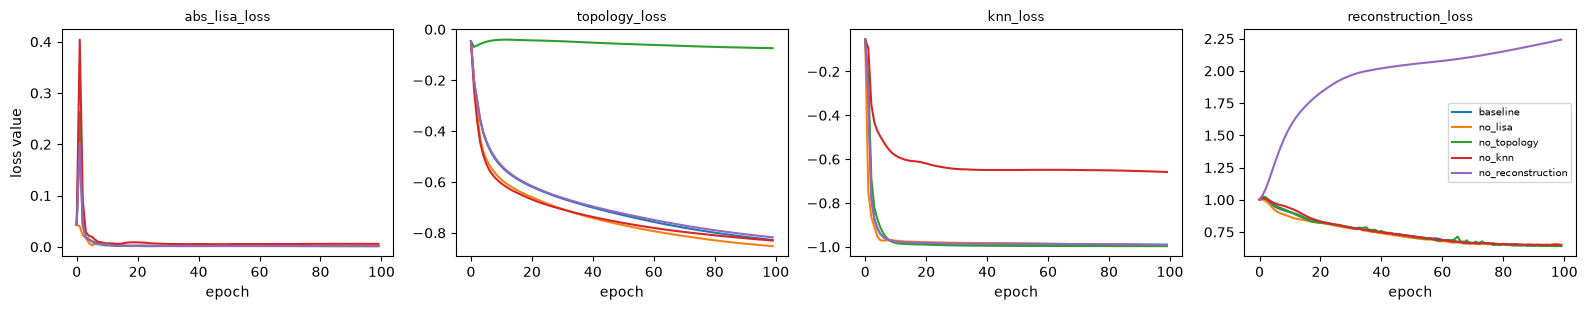

In [6]:
loss_names = list(FULL_WEIGHTS)
fig, axes = plt.subplots(1, len(loss_names), figsize=(4 * len(loss_names), 3.2), sharex=True)

for ax, loss_name in zip(axes, loss_names):
    for name, model in models.items():
        ax.plot(model.loss_history["loss"][loss_name], label=name, linewidth=1.5)
    ax.set_title(loss_name, fontsize=9)
    ax.set_xlabel("epoch")

axes[0].set_ylabel("loss value")
axes[-1].legend(fontsize=7, loc="best")
plt.tight_layout()

## Findings

Results with the batch-conditioned decoder (batch one-hot concatenated into the decoder's
input, so `reconstruction_loss` reflects per-batch-aware decoding):

| config             | batch_silhouette | celltype_silhouette | centroid_distance_corr | reconstruction_rel_error |
|---------------------|------------------:|----------------------:|------------------------:|---------------------------:|
| baseline            |           -0.0023 |                 0.7989 |                   0.6222 |                      0.6454 |
| no_lisa             |           -0.0000 |                 0.8660 |                   0.6014 |                      0.6444 |
| no_topology         |           -0.0010 |                 0.7140 |                   0.6060 |                      0.6408 |
| no_knn              |            0.0022 |                 0.4549 |                   0.8178 |                      0.6505 |
| no_reconstruction   |           -0.0030 |                 0.4848 |                   0.5981 |                      2.2449 |

- **`reconstruction_loss` still drives cell-type separation and information preservation.**
  Dropping it collapses `celltype_silhouette` (0.80 → 0.48) and blows up
  `reconstruction_rel_error` 3.5x (0.65 → 2.24). Conditioning the decoder on batch didn't
  remove the need for the loss term itself — without it, the transformed space still
  collapses information the decoder (batch-aware or not) can no longer recover.
- **`topology_loss` controls intra-batch geometry directly, but that's a narrower target
  than centroid-level geometry.** Removing it collapses the `topology_loss` metric itself
  (-0.83 → -0.07, i.e. near-zero correlation between each batch's original and transformed
  local structure), yet `centroid_distance_corr` — a coarser, type-level geometry measure —
  barely moves (0.622 → 0.606). Per-batch manifold structure and global type-centroid
  geometry are only loosely coupled here.
- **`knn_loss` trades cell-type coherence for centroid geometry.** `no_knn` is the *only*
  config that improves `centroid_distance_corr` (0.622 → 0.818, the best of all five), but
  it has the worst `celltype_silhouette` (0.4549). The cross-batch attraction that merges
  matching subpopulations from different batches distorts raw centroid-to-centroid distances
  to do so — a real trade-off, not a free win either way.
- **`abs_lisa_loss` has the smallest, closest-to-noise effect in this setup.** Dropping it
  barely moves any metric, and `celltype_silhouette` even ticks up slightly (0.799 → 0.866).
  `batch_silhouette` stays ≈0 in every config here, so the simulated batch effect (a simple
  additive shift) is apparently removed by `topology_loss`/`knn_loss` pressure alone, leaving
  little for LIBSA to do on top.
- **Batch mixing (`batch_silhouette`) is essentially solved in all five configs** — it's
  never the metric that separates them. The real differentiator is cell-type preservation
  vs. centroid-geometry fidelity, and that trade-off is dominated by `reconstruction_loss`
  and `knn_loss`, not by `abs_lisa_loss`.